# Riyadh / Grocery Demand Forecast

<a href="https://colab.research.google.com/github/manaralbader/retail-demand-forecast/blob/main/riyadh-grocery-demand-forecast.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>

In [1]:
import subprocess, sys

def _pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip_install("pandas", "numpy", "matplotlib", "statsmodels", "scikit-learn", "lightgbm")

import pathlib
import urllib.request

REPO = "manaralbader/retail-demand-forecast"
BRANCH = "main"

def fetch(rel_path: str) -> str:
    """Find rel_path in a local repo checkout, or download it from GitHub
    if it isn't there (a fresh Colab runtime with nothing cloned)."""
    for candidate in (rel_path, f"../{rel_path}"):
        if pathlib.Path(candidate).exists():
            return candidate
    dest = pathlib.Path(pathlib.Path(rel_path).name)
    if not dest.exists():
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{rel_path}"
        urllib.request.urlretrieve(url, dest)
    return str(dest)

sys.path.insert(0, str(pathlib.Path(fetch("common/metrics.py")).parent))
from metrics import mae, rmse, mase, coverage, interval_width
sys.path.insert(0, str(pathlib.Path(fetch("common/backtest.py")).parent))
from backtest import expanding_window_splits, run_backtest, seasonal_naive_forecast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

RNG_SEED = 20260912
np.random.seed(RNG_SEED)

## 1. Time Series Structure & Diagnostics

Riyadh / Grocery, daily units sold, 2023–2025.


1096 rows, 2023-01-01 to 2025-12-31
expected 1096 calendar days -> no gaps
count    1096.000000
mean      669.549270
std       206.684648
min       397.000000
25%       534.750000
50%       626.000000
75%       743.000000
max      2357.000000
Name: units_sold, dtype: float64


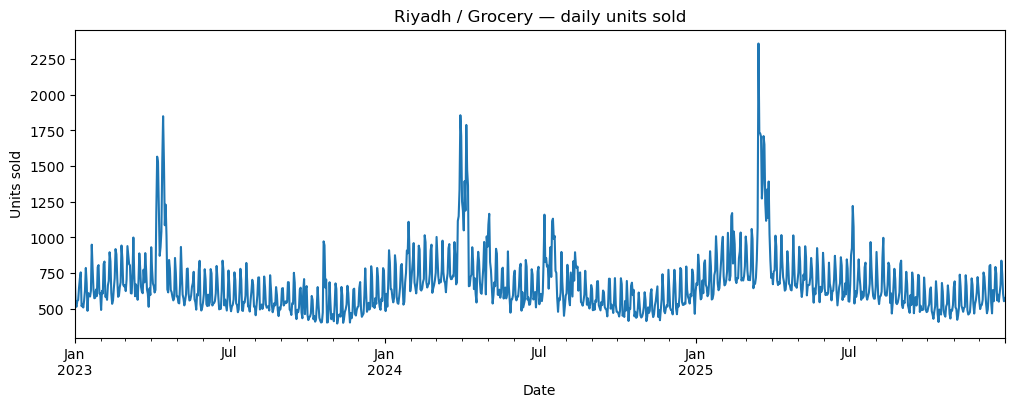

In [2]:
df = pd.read_csv(fetch("data/retail_demand.csv"), parse_dates=["date"])
riyadh_grocery = df[(df["region"] == "Riyadh") & (df["category"] == "Grocery")].copy()
riyadh_grocery = riyadh_grocery.sort_values("date").set_index("date")
y = riyadh_grocery["units_sold"]

expected_days = (y.index.max() - y.index.min()).days + 1
print(f"{len(y)} rows, {y.index.min().date()} to {y.index.max().date()}")
print(f"expected {expected_days} calendar days -> {'no gaps' if expected_days == len(y) else 'GAPS PRESENT, need to investigate'}")

y = y.asfreq("D")  # lock in a daily frequency now that we've confirmed there are no gaps
print(y.describe())

fig, ax = plt.subplots(figsize=(12, 4))
y.plot(ax=ax)
ax.set_title("Riyadh / Grocery — daily units sold")
ax.set_xlabel("Date")
ax.set_ylabel("Units sold")
plt.show()

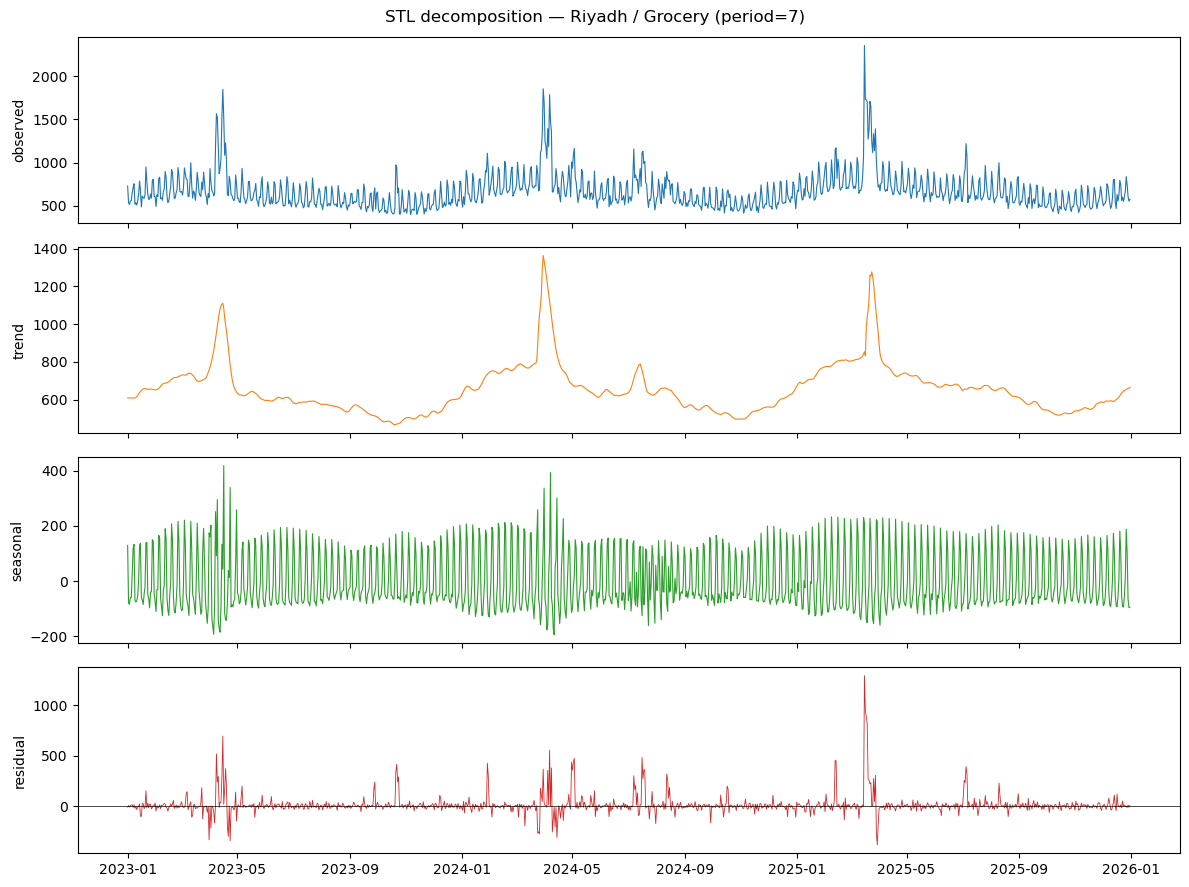

residual std: 104.68739531431723
largest 5 |residual| days:
date
2025-03-16    1293.844161
2025-03-17     942.499865
2025-03-18     885.541233
2025-03-19     819.675148
2023-04-15     693.547435
Name: resid, dtype: float64


In [3]:
from statsmodels.tsa.seasonal import STL

stl = STL(y, period=7, robust=True)
decomp = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(y.index, y.values, linewidth=0.8)
axes[0].set_ylabel("observed")
axes[1].plot(y.index, decomp.trend, linewidth=0.8, color="tab:orange")
axes[1].set_ylabel("trend")
axes[2].plot(y.index, decomp.seasonal, linewidth=0.8, color="tab:green")
axes[2].set_ylabel("seasonal")
axes[3].plot(y.index, decomp.resid, linewidth=0.6, color="tab:red")
axes[3].set_ylabel("residual")
axes[3].axhline(0, color="black", linewidth=0.5)
fig.suptitle("STL decomposition — Riyadh / Grocery (period=7)")
plt.tight_layout()
plt.show()

print("residual std:", np.std(decomp.resid))
print("largest 5 |residual| days:")
print(decomp.resid.abs().sort_values(ascending=False).head(5))

In [4]:
trend_start, trend_end = decomp.trend.dropna().iloc[0], decomp.trend.dropna().iloc[-1]
trend_change_pct = (trend_end - trend_start) / trend_start * 100

seasonal_amplitude = decomp.seasonal.iloc[:7].max() - decomp.seasonal.iloc[:7].min()

resid_share = decomp.resid.std() / y.std() * 100

print(f"trend: {trend_start:.1f} -> {trend_end:.1f} ({trend_change_pct:+.1f}% over the full period)")
print(f"weekly seasonal amplitude (peak-to-trough within one week): {seasonal_amplitude:.1f} units")
print(f"residual std as % of raw series std: {resid_share:.1f}%")

trend: 609.0 -> 664.1 (+9.0% over the full period)
weekly seasonal amplitude (peak-to-trough within one week): 213.4 units
residual std as % of raw series std: 50.7%


Trend is mild — +9% over three years, drift more than signal. Weekly seasonality is the strongest component: 213 units peak-to-trough, about a third of the mean level. The residual is large relative to the series (51% of its std), and the biggest misses aren't scattered noise — the four largest are consecutive days in March 2025, which looks like a promo shock STL folded into the residual rather than the seasonal term (expected, since STL's seasonal period is fixed at 7 and can't absorb a one-off event).


### Stationarity: ACF, PACF, and the ADF test

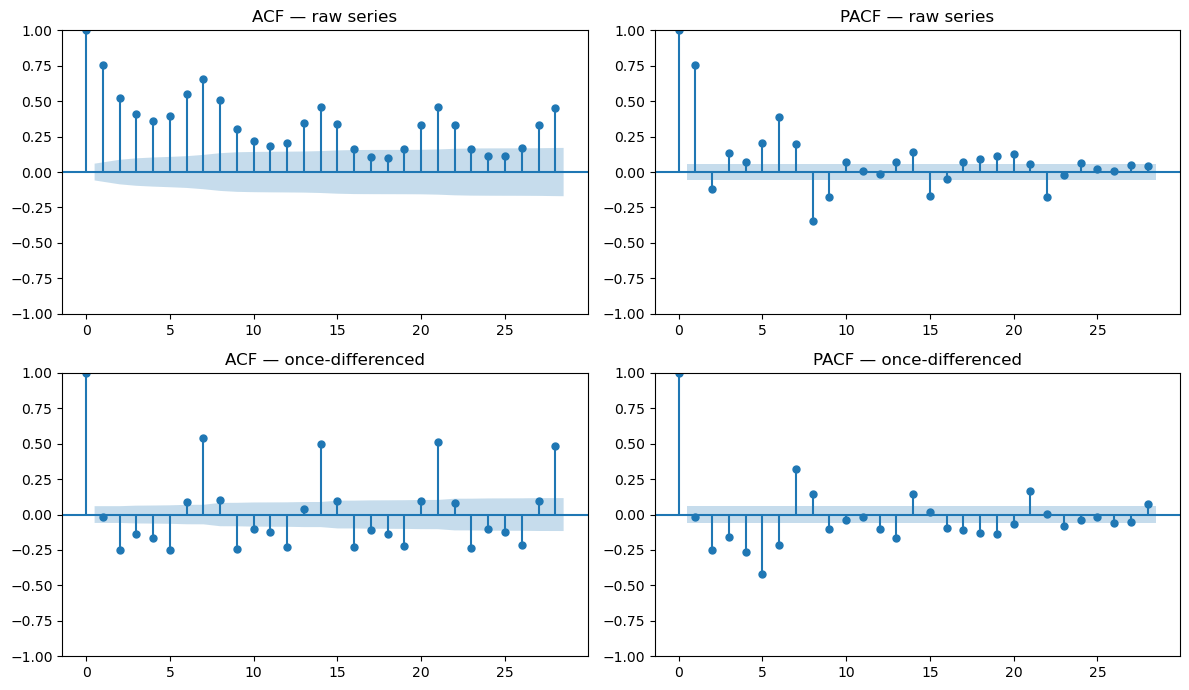

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

diffed = y.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(y, lags=28, ax=axes[0, 0])
axes[0, 0].set_title("ACF — raw series")
plot_pacf(y, lags=28, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF — raw series")
plot_acf(diffed, lags=28, ax=axes[1, 0])
axes[1, 0].set_title("ACF — once-differenced")
plot_pacf(diffed, lags=28, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF — once-differenced")
plt.tight_layout()
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

def report_adf(series, label):
    result = adfuller(series.dropna(), autolag="AIC", result_object=True)
    print(f"{label}")
    print(f"  ADF statistic: {result.statistic:.4f}")
    print(f"  p-value:       {result.pvalue:.6f}")
    print(f"  used lags:     {result.lags}")
    for level, cv in result.critical_values.items():
        print(f"  critical value ({level}): {cv:.4f}")
    verdict = "stationary (reject the unit-root null)" if result.pvalue < 0.05 else "NON-stationary (fail to reject the unit-root null)"
    print(f"  => {verdict}\n")
    return result.pvalue

pvalue_raw = report_adf(y, "Raw series")
pvalue_diff = report_adf(diffed, "Once-differenced series")

Raw series
  ADF statistic: -3.8721
  p-value:       0.002250
  used lags:     21
  critical value (1%): -3.4365
  critical value (5%): -2.8642
  critical value (10%): -2.5682
  => stationary (reject the unit-root null)

Once-differenced series
  ADF statistic: -9.8473
  p-value:       0.000000
  used lags:     22
  critical value (1%): -3.4365
  critical value (5%): -2.8642
  critical value (10%): -2.5682
  => stationary (reject the unit-root null)



PACF cuts off sharply after lag 1 with a clear spike at lag 7, the seasonal-AR signature of a weekly cycle; ACF decays slowly, typical of a series that's autocorrelated but not obviously non-stationary. The ADF test agrees: both the raw and differenced series reject the unit-root null (p=0.0023 raw, p≈0 differenced), so strictly the raw series is already stationary and differencing isn't required. That's consistent with the weak trend above — a slow +9% drift over three years isn't enough non-stationarity for ADF to flag. The SARIMA below is fit with d=0 on that basis, leaving the seasonal AR term to carry the weekly structure.


## 2. Classical Model — SARIMA

Starting point: SARIMA(1,0,1)(1,0,1)[7] — an AR/MA pair for the lag-1 autocorrelation the PACF showed, a seasonal (1,0,1) pair for the weekly cycle, d=0 per the ADF result above.


In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    y,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    trend="c",
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                        units_sold   No. Observations:                 1096
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -6752.965
Date:                           Tue, 22 Sep 2026   AIC                          13517.930
Time:                                   11:29:55   BIC                          13547.926
Sample:                               01-01-2023   HQIC                         13529.280
                                    - 12-31-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    166.1466     17.527      9.480      0.000     131.795     200.498
ar.L1          0.5753      0.021     27.366

c:\Users\Manar Albader\miniconda3\envs\ml\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


The seasonal MA term (`ma.S.L7`, p=0.465) wasn't significant and the fit threw a convergence warning, so it's dropped — `seasonal_order=(1,0,0,7)` instead of `(1,0,1,7)`. AIC improves (13517.9 → 13466.3), every remaining term is significant at the 5% level, and the fit converges cleanly. Final model: SARIMA(1,0,1)(1,0,0)[7].


In [8]:
sarima_model = SARIMAX(
    y,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 7),
    trend="c",
)
sarima_fit = sarima_model.fit(disp=False, maxiter=200)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         units_sold   No. Observations:                 1096
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 7)   Log Likelihood               -6728.162
Date:                            Tue, 22 Sep 2026   AIC                          13466.323
Time:                                    11:29:56   BIC                          13491.320
Sample:                                01-01-2023   HQIC                         13475.782
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     77.2754      7.717     10.014      0.000      62.151      92.400
ar.L1          0.7306      0.019   

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = sarima_fit.resid

lb_results = acorr_ljungbox(residuals, lags=[7, 14, 21, 28], return_df=True)
print(lb_results)

       lb_stat     lb_pvalue
7    52.038817  5.736611e-09
14   85.944315  2.201600e-12
21  141.722903  6.475604e-20
28  159.054040  2.821961e-20


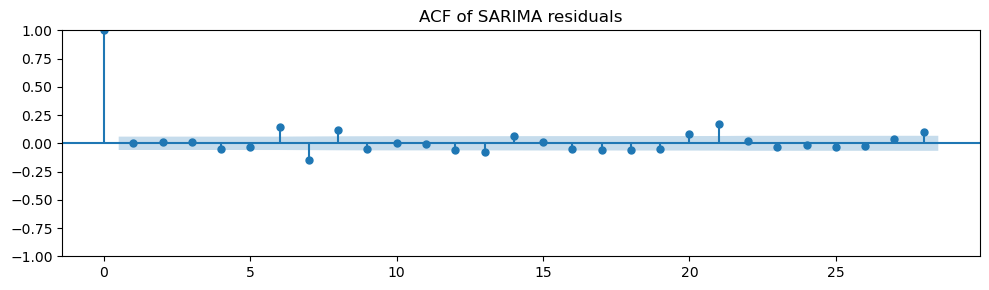

largest |residual ACF|, lags 1-28: 0.17492399220787888
at lag: 21


In [10]:
from statsmodels.tsa.stattools import acf

fig, ax = plt.subplots(figsize=(10, 3))
plot_acf(residuals, lags=28, ax=ax)
ax.set_title("ACF of SARIMA residuals")
plt.tight_layout()
plt.show()

resid_acf = acf(residuals, nlags=28)[1:]  # drop lag 0 (always 1.0)
print("largest |residual ACF|, lags 1-28:", np.abs(resid_acf).max())
print("at lag:", np.argmax(np.abs(resid_acf)) + 1)

The Ljung-Box row inside the model summary (lag 1 only) looks clean — Q=0.00, p=0.99. That's a weak check, though. Testing lags 7/14/21/28 directly tells a different story: p-values from 6e-9 to 3e-20, rejecting white noise at every one, and the residual ACF's largest remaining spike (0.17) sits at lag 21. So the residuals aren't clean — there's autocorrelation this order hasn't captured, most likely a slower cycle a (1,0,0)[7] seasonal term isn't built to catch. Worth flagging rather than stopping at the lag-1 check.


## 3. ML/GBM Model — LightGBM with Engineered Features


In [11]:
feat = pd.DataFrame({"y": y})

for lag in [1, 2, 7, 14, 21, 28]:
    feat[f"lag_{lag}"] = feat["y"].shift(lag)

for window in [7, 14, 28]:
    feat[f"roll_mean_{window}"] = feat["y"].shift(1).rolling(window).mean()
    feat[f"roll_std_{window}"] = feat["y"].shift(1).rolling(window).std()

feat["dayofweek"] = feat.index.dayofweek
feat["day"] = feat.index.day
feat["month"] = feat.index.month
feat["dayofyear"] = feat.index.dayofyear
feat["weekofyear"] = feat.index.isocalendar().week.astype(int)

feat = feat.dropna()

print(f"{len(feat)} rows remain after dropping warm-up NaNs (lost {len(y) - len(feat)} rows to the longest 28-day lag/window)")
feat.head()

1068 rows remain after dropping warm-up NaNs (lost 28 rows to the longest 28-day lag/window)


,y,lag_1,lag_2,lag_7,lag_14,lag_21,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_28,roll_std_28,dayofweek,day,month,dayofyear,weekofyear
date,,,,,,,,,,,,,,,,,,
2023-01-29,806.0,792.0,589.0,779.0,680.0,755.0,728.0,654.714286,92.977980,651.071429,117.179326,630.607143,108.173845,6,29,1,29,4
2023-01-30,607.0,806.0,792.0,637.0,486.0,518.0,535.0,658.571429,99.335890,660.071429,124.200498,633.392857,111.720995,0,30,1,30,5
2023-01-31,607.0,607.0,806.0,574.0,610.0,534.0,514.0,654.285714,101.053970,668.714286,115.026705,635.964286,110.190570,1,31,1,31,5
2023-02-01,492.0,607.0,607.0,577.0,595.0,509.0,555.0,659.000000,97.387542,668.500000,115.147230,639.285714,107.752754,2,1,2,32,5
2023-02-02,626.0,492.0,607.0,635.0,586.0,558.0,561.0,646.857143,113.312883,661.142857,123.212672,637.035714,110.207710,3,2,2,33,5


In [12]:
LAG_LIST = [1, 2, 7, 14, 21, 28]
ROLL_WINDOWS = [7, 14, 28]
FEATURE_COLS = (
    [f"lag_{k}" for k in LAG_LIST]
    + [f"roll_mean_{w}" for w in ROLL_WINDOWS]
    + [f"roll_std_{w}" for w in ROLL_WINDOWS]
    + ["dayofweek", "day", "month", "dayofyear", "weekofyear"]
)

def build_features(series: pd.Series) -> pd.DataFrame:
    f = pd.DataFrame({"y": series})
    for lag in LAG_LIST:
        f[f"lag_{lag}"] = f["y"].shift(lag)
    for window in ROLL_WINDOWS:
        f[f"roll_mean_{window}"] = f["y"].shift(1).rolling(window).mean()
        f[f"roll_std_{window}"] = f["y"].shift(1).rolling(window).std()
    f["dayofweek"] = f.index.dayofweek
    f["day"] = f.index.day
    f["month"] = f.index.month
    f["dayofyear"] = f.index.dayofyear
    f["weekofyear"] = f.index.isocalendar().week.astype(int)
    return f

# sanity check: should match what Cell 15 showed
feat_check = build_features(y).dropna()
print(f"{len(feat_check)} rows, {len(FEATURE_COLS)} feature columns")
assert len(feat_check) == 1068

1068 rows, 17 feature columns


Every rolling feature is built on `.shift(1)` before the window, so the row for day *t* only sees data through *t-1*, never *t* itself — same reasoning for the lags (minimum lag is 1). The multi-step forecast is recursive: each prediction gets appended to history to build the next step's features, so there's no peeking at real future actuals at any horizon either.


In [13]:
import lightgbm as lgb

def train_lgbm(y_train: pd.Series) -> lgb.LGBMRegressor:
    train_feat = build_features(y_train).dropna()
    model = lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=15,
        random_state=RNG_SEED,
        verbosity=-1,
    )
    model.fit(train_feat[FEATURE_COLS], train_feat["y"])
    return model

def recursive_forecast(model: lgb.LGBMRegressor, history: pd.Series, horizon: int) -> np.ndarray:
    history = history.copy()
    preds = []
    for _ in range(horizon):
        next_date = history.index[-1] + pd.Timedelta(days=1)
        row = build_features(pd.concat([history, pd.Series([np.nan], index=[next_date])])).iloc[[-1]]
        pred = model.predict(row[FEATURE_COLS])[0]
        preds.append(pred)
        history.loc[next_date] = pred
    return np.array(preds)

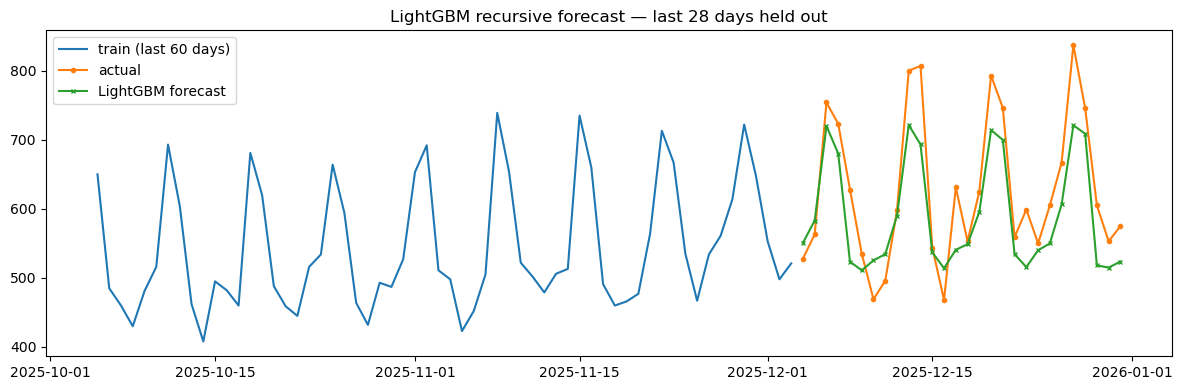

demo MAE: 50.30123172676141
demo RMSE: 59.66472798468656


In [14]:
test_horizon = 28
train_demo = y.iloc[:-test_horizon]
test_demo = y.iloc[-test_horizon:]

demo_model = train_lgbm(train_demo)
demo_preds = recursive_forecast(demo_model, train_demo, test_horizon)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_demo.index[-60:], train_demo.values[-60:], label="train (last 60 days)")
ax.plot(test_demo.index, test_demo.values, label="actual", marker="o", markersize=3)
ax.plot(test_demo.index, demo_preds, label="LightGBM forecast", marker="x", markersize=3)
ax.legend()
ax.set_title("LightGBM recursive forecast — last 28 days held out")
plt.tight_layout()
plt.show()

print("demo MAE:", mae(test_demo.values, demo_preds))
print("demo RMSE:", rmse(test_demo.values, demo_preds))

(Single 28-day holdout — just a sanity check on the pipeline before the real backtest below.)


## 4. Walk-Forward Backtest

5-fold expanding window (`min_train_size=365`, `horizon=14`). Expanding, not rolling, because this series has no structural break to discard — unlike `workforce_demand.csv` — so there's no reason to throw away early history; more data only helps SARIMA's seasonal estimate and LightGBM's lag features. Fold 0's actual training size comes out to 1026 days, well above the 365 floor — that floor is a minimum, not a target, and five 14-day folds only reserve 70 of the 1096 days for testing.


In [15]:
splits = expanding_window_splits(n=len(y), n_folds=5, horizon=14, min_train_size=365)
print(f"{len(splits)} folds; fold 0 train size = {splits[0][0].stop}, last fold test window = {splits[-1][1]}")

def fit_predict_baseline(y_train, horizon):
    return seasonal_naive_forecast(y_train, horizon, period=7)

def fit_predict_sarima(y_train, horizon):
    model = SARIMAX(y_train, order=(1, 0, 1), seasonal_order=(1, 0, 0, 7), trend="c")
    fit = model.fit(disp=False, maxiter=200)
    return fit.get_forecast(steps=horizon).predicted_mean

def fit_predict_lgbm(y_train, horizon):
    dates = y.index[:len(y_train)]
    series = pd.Series(y_train, index=dates)
    model = train_lgbm(series)
    return recursive_forecast(model, series, horizon)

results_baseline = run_backtest(y.values, splits, fit_predict_baseline)
results_sarima = run_backtest(y.values, splits, fit_predict_sarima)
results_lgbm = run_backtest(y.values, splits, fit_predict_lgbm)

print("folds completed:", len(results_baseline), len(results_sarima), len(results_lgbm))

5 folds; fold 0 train size = 1026, last fold test window = slice(1082, 1096, None)
folds completed: 5 5 5


In [16]:
def score_backtest(results, model_name):
    rows = []
    for r in results:
        rows.append({
            "model": model_name,
            "fold": r["fold"],
            "mae": mae(r["y_true"], r["y_pred"]),
            "rmse": rmse(r["y_true"], r["y_pred"]),
            "mase": mase(r["y_true"], r["y_pred"], r["y_train"], seasonal_period=7),
        })
    return pd.DataFrame(rows)

scores = pd.concat([
    score_backtest(results_baseline, "seasonal_naive"),
    score_backtest(results_sarima, "SARIMA"),
    score_backtest(results_lgbm, "LightGBM"),
], ignore_index=True)

print(scores.to_string(index=False))

summary = scores.groupby("model")[["mae", "rmse", "mase"]].mean().round(2)
summary = summary.reindex(["seasonal_naive", "SARIMA", "LightGBM"])
print()
print("mean across 5 folds:")
print(summary)

         model  fold       mae      rmse     mase
seasonal_naive     0 36.142857 41.594986 0.396030
seasonal_naive     1 35.714286 42.945148 0.394260
seasonal_naive     2 40.285714 48.133742 0.448786
seasonal_naive     3 58.714286 70.185469 0.659655
seasonal_naive     4 61.214286 69.441136 0.690493
        SARIMA     0 62.075481 73.999433 0.680182
        SARIMA     1 61.966100 77.750825 0.684061
        SARIMA     2 38.607728 46.887411 0.430093
        SARIMA     3 75.902067 88.577714 0.852760
        SARIMA     4 48.500749 57.647315 0.547085
      LightGBM     0 29.630897 31.312780 0.324676
      LightGBM     1 31.078612 42.040194 0.343085
      LightGBM     2 32.425044 38.942426 0.361217
      LightGBM     3 49.046699 59.521971 0.551040
      LightGBM     4 38.986742 45.696651 0.439768

mean across 5 folds:
                  mae   rmse  mase
model                             
seasonal_naive  46.41  54.46  0.52
SARIMA          57.41  68.97  0.64
LightGBM        36.23  43.50  0.40


## 5. Accuracy Metrics

MASE, not WAPE, is the scale-free metric here — this series has no zero or near-zero days (min 397 units), so MAPE-style ratios aren't distorted, and MASE answers the question this backtest is actually asking: does the model beat repeating last week?

SARIMA loses to the naive baseline (MASE 0.64 vs 0.52) — consistent with the residual autocorrelation flagged in section 2, whatever's left unmodeled is apparently enough to hurt it in a genuine holdout, not just in-sample. LightGBM is the only model that beats naive (0.40).


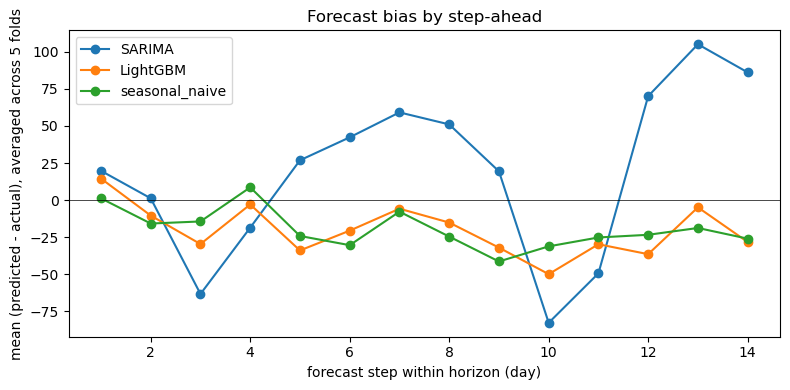

SARIMA bias, step 1 vs step 14: 19.774290228410074 vs 86.17125681602559


In [17]:
def per_step_bias(results, horizon=14):
    step_errors = np.zeros(horizon)
    for r in results:
        step_errors += (r["y_pred"] - r["y_true"])
    return step_errors / len(results)

sarima_bias = per_step_bias(results_sarima)
lgbm_bias = per_step_bias(results_lgbm)
naive_bias = per_step_bias(results_baseline)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 15), sarima_bias, marker="o", label="SARIMA")
ax.plot(range(1, 15), lgbm_bias, marker="o", label="LightGBM")
ax.plot(range(1, 15), naive_bias, marker="o", label="seasonal_naive")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("forecast step within horizon (day)")
ax.set_ylabel("mean (predicted - actual), averaged across 5 folds")
ax.legend()
ax.set_title("Forecast bias by step-ahead")
plt.tight_layout()
plt.show()

print("SARIMA bias, step 1 vs step 14:", sarima_bias[0], "vs", sarima_bias[-1])

Bias grows with horizon for every model — SARIMA's is +19.8 units at step 1 vs +86.2 at step 14 — errors compound over the 14-day window instead of staying flat, expected for a recursive/iterated forecast.


## 6. Probabilistic Forecast

SARIMA's native `get_forecast().conf_int()` at the 80% level, scored across all 5 backtest folds.


In [18]:
NOMINAL_LEVEL = 0.80
alpha = 1 - NOMINAL_LEVEL

interval_true, interval_lower, interval_upper = [], [], []

for train_slice, test_slice in splits:
    y_train_fold = y.values[train_slice]
    y_true_fold = y.values[test_slice]
    horizon = test_slice.stop - test_slice.start

    model = SARIMAX(y_train_fold, order=(1, 0, 1), seasonal_order=(1, 0, 0, 7), trend="c")
    fit = model.fit(disp=False, maxiter=200)
    ci = fit.get_forecast(steps=horizon).conf_int(alpha=alpha)

    interval_true.append(y_true_fold)
    interval_lower.append(ci[:, 0])
    interval_upper.append(ci[:, 1])

interval_true = np.concatenate(interval_true)
interval_lower = np.concatenate(interval_lower)
interval_upper = np.concatenate(interval_upper)

cov = coverage(interval_true, interval_lower, interval_upper)
width = interval_width(interval_lower, interval_upper)

print(f"nominal level: {NOMINAL_LEVEL:.0%}")
print(f"empirical coverage: {cov:.3f}")
print(f"mean interval width: {width:.2f} units")

nominal level: 80%
empirical coverage: 1.000
mean interval width: 425.21 units


100% empirical coverage against an 80% nominal target isn't good news by itself — an interval that's too wide will "cover" everything, and that's what's happening here: 425 units wide on a series with mean 670 and std 207, roughly ±2 standard deviations for a band that should be closer to ±1.28σ. That lines up with the residual-structure issue from section 2 — `sigma2` in the SARIMA fit is inflated by autocorrelation the model didn't capture, so the interval comes out wider than it should. Not miscalibrated on the unsafe side, but not useful for planning as-is; worth tightening (or conformal-calibrating) before it goes anywhere near a stocking decision.


## 7. Model Comparison & Recommendation


In [19]:
final_summary = summary.copy()
final_summary["beats_naive"] = final_summary["mase"] < summary.loc["seasonal_naive", "mase"]
print(final_summary)

print()
print(f"SARIMA 80% interval — empirical coverage: {cov:.1%}, mean width: {width:.1f} units")

                  mae   rmse  mase  beats_naive
model                                          
seasonal_naive  46.41  54.46  0.52        False
SARIMA          57.41  68.97  0.64        False
LightGBM        36.23  43.50  0.40         True

SARIMA 80% interval — empirical coverage: 100.0%, mean width: 425.2 units


**LightGBM** is the model I'd deploy for this series.

- **Accuracy** — it's the only model beating seasonal-naive on the backtest (MASE 0.40 vs 0.52), by a wider margin than SARIMA loses by. Not the whole argument, but not nothing.
- **Interpretability** — SARIMA's coefficients are directly readable (`ar.S.L7=0.57` is literally "how much of last week repeats"); LightGBM's feature importances are a weaker substitute. For a demand-planning series where the questions are mostly *how much, when* rather than *why*, that trade-off is acceptable.
- **Interval support** — this is SARIMA's real advantage, and the honest gap in this notebook: LightGBM only produces point forecasts here. If the deployment needs uncertainty bounds (safety stock, for instance), that has to be built — conformal calibration on the LightGBM residuals is the natural next step — before it fully replaces SARIMA. Shipping the point forecast alone and dropping intervals isn't a fair trade.
- **History length & compute** — both trained fine on ~2.8 years per fold and neither was expensive; SARIMA needed manual attention (the seasonal-MA term had to be dropped by hand), LightGBM's pipeline is more mechanical.

Net: LightGBM for the point forecast, but this isn't done until it has an interval — SARIMA's is already wider than it should be, and LightGBM currently has none at all.
